# Tarea M25-CD - YAIR PALOMARES

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [74]:
drugs = pd.read_csv("drugs.csv")
drugs["Origen"] = "NA"
cont = 0
for i in drugs["Drug"]:
    if (i == "drugA") or (i == "drugB") or (i == "drugC"):
        drugs["Origen"][cont] = 0
    else:
        drugs["Origen"][cont] = 1
    cont = cont+1
drugs

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Origen
0,23,F,HIGH,HIGH,25.355,drugY,1
1,47,M,LOW,HIGH,13.093,drugC,0
2,47,M,LOW,HIGH,10.114,drugC,0
3,28,F,NORMAL,HIGH,7.798,drugX,1
4,61,F,LOW,HIGH,18.043,drugY,1
...,...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC,0
196,16,M,LOW,HIGH,12.006,drugC,0
197,52,M,NORMAL,HIGH,9.894,drugX,1
198,23,M,NORMAL,NORMAL,14.020,drugX,1


In [87]:
#Selección de las características para la predicción y variable objetivo
feature_cols = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]
x = drugs[feature_cols].values
y = drugs["Origen"].values
y=y.astype('int')

In [88]:
#Se convierten variables cualitativas a escala numérica
from sklearn import preprocessing

Cod_Sex = preprocessing.LabelEncoder()
Cod_Sex.fit(["M", "F"])
x[:,1] = Cod_Sex.transform(x[:,1])

Cod_BP = preprocessing.LabelEncoder()
Cod_BP.fit(["LOW", "NORMAL", "HIGH"])
x[:,2] = Cod_BP.transform(x[:,2])

Cod_Cholesterol = preprocessing.LabelEncoder()
Cod_Cholesterol.fit(["NORMAL", "HIGH"])
x[:,3] = Cod_Cholesterol.transform(x[:,3])

In [89]:
#Creación de grupos de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 1)

## Regresión logística con Solucionador (Solver): sag

In [90]:
#Ajuste del modelo
model = LogisticRegression(solver="sag")
clf = model.fit(x_train, y_train)

#Predicción de etiquetas de clase sobre datos de prueba
y_pred = model.predict(x_test)

#Impresión de coeficientes de la regresión de puntajes
print("Intercepto (Beta 0)", clf.intercept_)
print("Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5)", clf.coef_)
print("----------------------------------------------------------------------------------------------------------------------")
#Reporte de clasificación
print(classification_report(y_test, y_pred))

Intercepto (Beta 0) [-0.30859865]
Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5) [[-0.03187963 -0.12697958  0.91657337  0.25981315  0.14081759]]
----------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.64      0.78        14
           1       0.90      1.00      0.95        46

    accuracy                           0.92        60
   macro avg       0.95      0.82      0.87        60
weighted avg       0.92      0.92      0.91        60



## Regresión logística con Solucionador (Solver): newton-cg

In [99]:
#Ajuste del modelo
model = LogisticRegression(solver="newton-cg")
clf = model.fit(x_train, y_train)

#Predicción de etiquetas de clase sobre datos de prueba
y_pred = model.predict(x_test)

#Impresión de coeficientes de la regresión de puntajes
print("Intercepto (Beta 0)", clf.intercept_)
print("Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5)", clf.coef_)
print("----------------------------------------------------------------------------------------------------------------------")
#Reporte de clasificación
print(classification_report(y_test, y_pred))

Intercepto (Beta 0) [-10.93201516]
Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5) [[0.01389525 0.1379319  3.14174722 2.16163836 0.60546876]]
----------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.98      1.00      0.99        46

    accuracy                           0.98        60
   macro avg       0.99      0.96      0.98        60
weighted avg       0.98      0.98      0.98        60



## Regresión logística con Solucionador (Solver): liblinear

In [92]:
#Ajuste del modelo
model = LogisticRegression(solver="liblinear")
clf = model.fit(x_train, y_train)

#Predicción de etiquetas de clase sobre datos de prueba
y_pred = model.predict(x_test)

#Impresión de coeficientes de la regresión de puntajes
print("Intercepto (Beta 0)", clf.intercept_)
print("Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5)", clf.coef_)
print("----------------------------------------------------------------------------------------------------------------------")
#Reporte de clasificación
print(classification_report(y_test, y_pred))

Intercepto (Beta 0) [-3.22816315]
Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5) [[-0.02274502 -0.22931494  1.92536996  1.18113954  0.24969711]]
----------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.98      1.00      0.99        46

    accuracy                           0.98        60
   macro avg       0.99      0.96      0.98        60
weighted avg       0.98      0.98      0.98        60



## Regresión logística con Solucionador (Solver): saga

In [93]:
#Ajuste del modelo
model = LogisticRegression(solver="saga")
clf = model.fit(x_train, y_train)

#Predicción de etiquetas de clase sobre datos de prueba
y_pred = model.predict(x_test)

#Impresión de coeficientes de la regresión de puntajes
print("Intercepto (Beta 0)", clf.intercept_)
print("Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5)", clf.coef_)
print("----------------------------------------------------------------------------------------------------------------------")
#Reporte de clasificación
print(classification_report(y_test, y_pred))

Intercepto (Beta 0) [-0.14338333]
Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5) [[-0.02841349 -0.06975573  0.58212905  0.13741358  0.13603053]]
----------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.57      0.73        14
           1       0.88      1.00      0.94        46

    accuracy                           0.90        60
   macro avg       0.94      0.79      0.83        60
weighted avg       0.91      0.90      0.89        60



## Regresión logística con Solucionador (Solver): lbfgs

In [94]:
#Ajuste del modelo
model = LogisticRegression(solver="lbfgs")
clf = model.fit(x_train, y_train)

#Predicción de etiquetas de clase sobre datos de prueba
y_pred = model.predict(x_test)

#Impresión de coeficientes de la regresión de puntajes
print("Intercepto (Beta 0)", clf.intercept_)
print("Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5)", clf.coef_)
print("----------------------------------------------------------------------------------------------------------------------")
#Reporte de clasificación
print(classification_report(y_test, y_pred))

Intercepto (Beta 0) [-10.93198905]
Pesos de cada variable (Beta 1, Beta 2, ..., Beta 5) [[0.0138946  0.13794847 3.14175844 2.16163574 0.60546537]]
----------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.98      1.00      0.99        46

    accuracy                           0.98        60
   macro avg       0.99      0.96      0.98        60
weighted avg       0.98      0.98      0.98        60



### Luego de la experimentación con los diferentes métodos de optimización aplicando la regresión logística a los datos, se concluye que los métodos newton-cg, liblinear y lbfgs son los que tienen un mejor desempeño, esto de acuerdo con los indicadores del reporte de clasificación de los modelos.

In [100]:
# Predicción de probabilidades para casos particulares
y_pred_probs = clf.predict_proba(x_test)[:,1]
y_pred_probs = np.round(y_pred_probs, 0)

#Convertir el data frame a un arreglo
#y_test = y_test.to_numpy()
y_test = [int(numeric_string) for numeric_string in y_test]

# Graficación de la curva ROC y cálculo del área bajo ella
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
# fpr = false positive rate
# tpr = true positive rate
# thresholds = límites para valores de p (por default el valor de 0.5)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
auc = roc_auc_score(y_test, y_pred_probs)

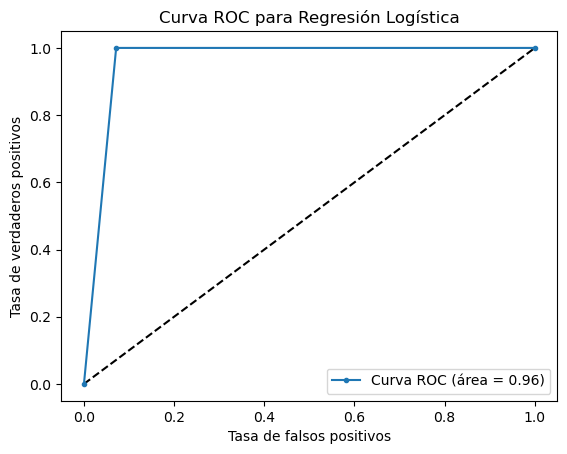

In [101]:
#Graficación de la curva ROC
plt.plot([0,1], [0,1], "k--")
plt.plot(fpr, tpr, marker=".", label="Curva ROC (área = %0.2f)" % auc)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc = "lower right")
plt.title("Curva ROC para Regresión Logística")
plt.show()

### De acuerdo con las estadísticas de los modelos recomendados, estos tuvieron una predicción global del 98%, así como un promedio simple en los indicadores de precisión, recuperación y f1-score del 99%, 96% y 98% respectivamente. Por otro lado, considerando la curva ROC, estos modelos tienen un área bajo la curva del 0.96, lo que nos dice que en un 96% de los casos se logrará distinguir de manera correcta un caso positivo de un negativo.